# 07 — Assemble Feature Matrix

Join all per-cell feature DataFrames into a single matrix ready for ML.

**Sources:**
- `dem_features.pkl` — elevation, slope, aspect, relief (9 features)
- `ndvi_features.pkl` — NDVI std (1 feature; mean dropped as low-signal)
- `climate_features.pkl` — tmean, tmin, tmax, ppt, vpdmax, ffd, gdd, temp_range (8 features)
- `soil_features.pkl` — ph, soc, sand, silt, clay, cec (6 features)

**Total: ~24 features × ~8,900 cells**

**Outputs:**
- `data/processed/features.pkl` — full feature matrix with cell_id
- `data/processed/features_scaled.pkl` — StandardScaler-normalized version for ML
- `data/processed/scaler.pkl` — fitted scaler (for inverse transform later)
- `img/07_feature_matrix.png` — correlation heatmap + missing data overview

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

RAW  = Path('../data/raw')
PROC = Path('../data/processed')
IMG  = Path('../img')

/home/simonhans/anaconda3/lib/python3.7/site-packages/geopandas/_compat.py:115: UserWarning: The Shapely GEOS version (3.11.4-CAPI-1.17.4) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  shapely_geos_version, geos_capi_version_string


## 1. Load all feature tables

In [2]:
dem     = pd.read_pickle(PROC / 'dem_features.pkl')
ndvi    = pd.read_pickle(PROC / 'ndvi_features.pkl')
climate = pd.read_pickle(PROC / 'climate_features.pkl')
soil    = pd.read_pickle(PROC / 'soil_features.pkl')

print('dem:    ', dem.shape,     dem.columns.tolist())
print('ndvi:   ', ndvi.shape,    ndvi.columns.tolist())
print('climate:', climate.shape, climate.columns.tolist())
print('soil:   ', soil.shape,    soil.columns.tolist())

dem:     (8648, 9) ['cell_id', 'elev_mean', 'elev_min', 'elev_max', 'elev_std', 'slope_mean', 'aspect_cos', 'aspect_sin', 'relief']
ndvi:    (8923, 5) ['cell_id', 'ndvi_min', 'ndvi_max', 'ndvi_mean', 'ndvi_std']
climate: (8923, 9) ['cell_id', 'tmean', 'tmin', 'tmax', 'ppt', 'vpdmax', 'ffd', 'gdd', 'temp_range']
soil:    (8923, 7) ['cell_id', 'ph', 'soc', 'sand', 'silt', 'clay', 'cec']


## 2. Join on cell_id

In [3]:
# Drop ndvi_mean — low signal in uniformly forested landscape (see notebook 04)
# Keep ndvi_std as a proxy for within-cell vegetation heterogeneity
ndvi_keep = ndvi[['cell_id', 'ndvi_std']].copy()

features = (
    dem
    .merge(ndvi_keep, on='cell_id', how='left')
    .merge(climate,   on='cell_id', how='left')
    .merge(soil,      on='cell_id', how='left')
)

print(f'Feature matrix: {features.shape}')
print(f'Columns: {features.columns.tolist()}')

Feature matrix: (8648, 24)
Columns: ['cell_id', 'elev_mean', 'elev_min', 'elev_max', 'elev_std', 'slope_mean', 'aspect_cos', 'aspect_sin', 'relief', 'ndvi_std', 'tmean', 'tmin', 'tmax', 'ppt', 'vpdmax', 'ffd', 'gdd', 'temp_range', 'ph', 'soc', 'sand', 'silt', 'clay', 'cec']


## 3. Audit missing data

In [4]:
missing = features.isnull().sum()
missing_pct = (missing / len(features) * 100).round(1)
miss_df = pd.DataFrame({'missing': missing, 'pct': missing_pct})
miss_df = miss_df[miss_df['missing'] > 0].sort_values('pct', ascending=False)

if len(miss_df):
    print('Columns with missing values:')
    print(miss_df.to_string())
else:
    print('No missing values.')

print(f'\nComplete rows (no NaN): {features.dropna().shape[0]:,} / {len(features):,}')

No missing values.

Complete rows (no NaN): 8,648 / 8,648


In [5]:
# Drop cells with no DEM coverage (ocean / outside boundary)
# For remaining NaNs: median-impute per column — affects soil at edges only
n_before = len(features)
features = features[features['elev_mean'].notna()].reset_index(drop=True)
print(f'Dropped {n_before - len(features)} cells with no DEM coverage')

for col in features.columns[1:]:   # skip cell_id
    if features[col].isna().any():
        med = features[col].median()
        features[col] = features[col].fillna(med)
        print(f'  Imputed {col} with median {med:.3f}')

print(f'\nFinal feature matrix: {features.shape}')
assert features.isnull().sum().sum() == 0, 'Still has NaNs!'
print('No NaNs remaining.')

Dropped 0 cells with no DEM coverage

Final feature matrix: (8648, 24)
No NaNs remaining.


## 4. Scale features for ML

In [6]:
feature_cols = [c for c in features.columns if c != 'cell_id']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features[feature_cols])
features_scaled = pd.DataFrame(X_scaled, columns=feature_cols)
features_scaled.insert(0, 'cell_id', features['cell_id'])

print(f'Scaled: mean≈0, std≈1 per column')
print(features_scaled[feature_cols].describe().round(2))

Scaled: mean≈0, std≈1 per column
       elev_mean  elev_min  elev_max  elev_std  slope_mean  aspect_cos  \
count    8648.00   8648.00   8648.00   8648.00     8648.00     8648.00   
mean       -0.00     -0.00      0.00     -0.00        0.00        0.00   
std         1.00      1.00      1.00      1.00        1.00        1.00   
min        -1.36     -1.12     -1.58     -1.89       -2.31       -0.62   
25%        -0.78     -0.83     -0.71     -0.58       -0.36       -0.58   
50%        -0.16     -0.23     -0.11      0.00        0.14       -0.43   
75%         0.64      0.63      0.65      0.63        0.64        0.00   
max         3.59      4.03      3.36      4.74        2.58        2.88   

       aspect_sin   relief  ndvi_std    tmean  ...   vpdmax      ffd      gdd  \
count     8648.00  8648.00   8648.00  8648.00  ...  8648.00  8648.00  8648.00   
mean         0.00     0.00     -0.00     0.00  ...    -0.00     0.00     0.00   
std          1.00     1.00      1.00     1.00  ...     1.

## 5. Correlation heatmap

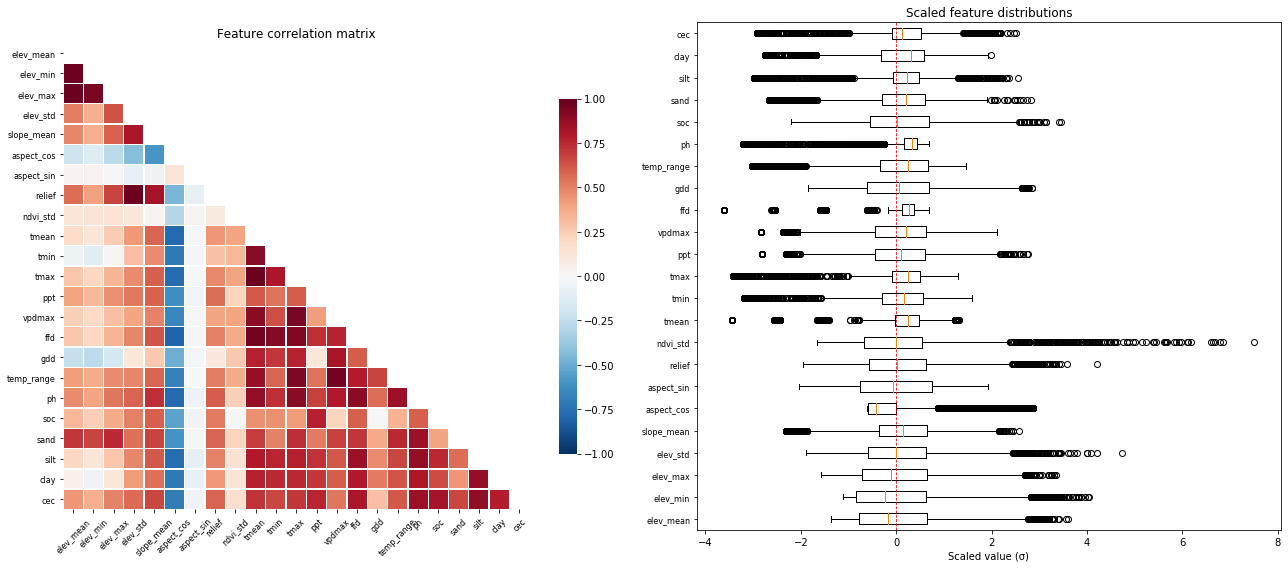

Saved img/07_feature_matrix.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Correlation matrix
corr = features[feature_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=axes[0], cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.3,
            cbar_kws={'shrink': 0.7}, annot=False)
axes[0].set_title('Feature correlation matrix', fontsize=12)
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].tick_params(axis='y', labelsize=8)

# Feature distributions (violin)
axes[1].set_title('Scaled feature distributions', fontsize=12)
scaled_long = features_scaled[feature_cols].melt(var_name='feature', value_name='value')
axes[1].boxplot(
    [features_scaled[col].values for col in feature_cols],
    labels=feature_cols, vert=False,
)
axes[1].axvline(0, color='red', linewidth=0.8, linestyle='--')
axes[1].tick_params(axis='y', labelsize=8)
axes[1].set_xlabel('Scaled value (σ)')

plt.tight_layout()
plt.savefig('../img/07_feature_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved img/07_feature_matrix.png')

## 6. Save

In [8]:
features.to_pickle(PROC / 'features.pkl')
features_scaled.to_pickle(PROC / 'features_scaled.pkl')
with open(PROC / 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print('Saved:')
print('  data/processed/features.pkl')
print('  data/processed/features_scaled.pkl')
print('  data/processed/scaler.pkl')
print()
print(f'Shape: {features.shape}')
print(f'Features: {feature_cols}')
print()
print('Data wrangling complete. Next: ML/01_model.ipynb')

Saved:
  data/processed/features.pkl
  data/processed/features_scaled.pkl
  data/processed/scaler.pkl

Shape: (8648, 24)
Features: ['elev_mean', 'elev_min', 'elev_max', 'elev_std', 'slope_mean', 'aspect_cos', 'aspect_sin', 'relief', 'ndvi_std', 'tmean', 'tmin', 'tmax', 'ppt', 'vpdmax', 'ffd', 'gdd', 'temp_range', 'ph', 'soc', 'sand', 'silt', 'clay', 'cec']

Data wrangling complete. Next: ML/01_model.ipynb
